In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import contextily as ctx
import matplotlib.pyplot as plt
import xyzservices as xyz
import zarr
import coiled
#import hvplot.xarray
#import cartopy.crs as ccrs
from global_snowmelt_runoff_onset.config import Config, Tile
import easysnowdata

In [29]:
sierra_nevada_bbox = (-121.0, 36.5, -118.0, 39.5)
cop30_dem_da = easysnowdata.topography.get_copernicus_dem(bbox_input=sierra_nevada_bbox).compute()
cop30_dem_da

<xarray.DataArray 'data' (latitude: 10801, longitude: 10801)> Size: 467MB
array([[ 960.2157 ,  951.1836 ,  953.4352 , ..., 1866.2649 , 1866.8376 ,
        1866.9583 ],
       [ 969.0814 ,  961.5054 ,  957.45746, ..., 1885.8693 , 1886.7074 ,
        1886.1449 ],
       [ 975.172  ,  966.1749 ,  962.08545, ..., 1907.8345 , 1906.4137 ,
        1903.1848 ],
       ...,
       [ 835.24457,  834.1277 ,  832.30756, ..., 1083.9363 , 1084.0005 ,
        1084.0616 ],
       [ 817.57043,  814.1866 ,  812.32886, ..., 1083.7612 , 1083.8286 ,
        1084.     ],
       [ 799.3549 ,  795.15546,  795.4757 , ..., 1083.8171 , 1083.7097 ,
        1083.763  ]], shape=(10801, 10801), dtype=float32)
Coordinates:
  * latitude     (latitude) float64 86kB 39.5 39.5 39.5 39.5 ... 36.5 36.5 36.5
  * longitude    (longitude) float64 86kB -121.0 -121.0 -121.0 ... -118.0 -118.0
    spatial_ref  int32 4B 4326
    time         datetime64[ns] 8B 2021-04-22

In [39]:
# sample point without reprojecting first
point_lon = -119.0064812
point_lat = 37.4602797
dem_value = cop30_dem_da.sel(longitude=point_lon, latitude=point_lat, method='nearest').values
print(f"DEM value at coordinates ({point_lon}, {point_lat}): {dem_value} meters")

DEM value at coordinates (-119.0064812, 37.4602797): 3492.88427734375 meters


In [42]:
from pyproj import Transformer

# Transformer from WGS84 3D (4979) to WGS84 + EGM2008 (4326+3855)
# Note: Always set always_xy=True for consistent (lon, lat, height) order
transformer = Transformer.from_crs("EPSG:4326+3855","EPSG:4979", always_xy=True)
new_lon, new_lat, new_height = transformer.transform(point_lon, point_lat, dem_value)
print(f"Transformed coordinates: ({new_lon}, {new_lat}, {new_height})")


Transformed coordinates: (-119.0064812, 37.4602797, 3468.2746640654696)


In [34]:
cop_dem_correct_vcrs_da = cop30_dem_da.rio.write_crs("EPSG:4326+3855", inplace=True)
cop_dem_correct_vcrs_da

<xarray.DataArray 'data' (latitude: 10801, longitude: 10801)> Size: 467MB
array([[ 960.2157 ,  951.1836 ,  953.4352 , ..., 1866.2649 , 1866.8376 ,
        1866.9583 ],
       [ 969.0814 ,  961.5054 ,  957.45746, ..., 1885.8693 , 1886.7074 ,
        1886.1449 ],
       [ 975.172  ,  966.1749 ,  962.08545, ..., 1907.8345 , 1906.4137 ,
        1903.1848 ],
       ...,
       [ 835.24457,  834.1277 ,  832.30756, ..., 1083.9363 , 1084.0005 ,
        1084.0616 ],
       [ 817.57043,  814.1866 ,  812.32886, ..., 1083.7612 , 1083.8286 ,
        1084.     ],
       [ 799.3549 ,  795.15546,  795.4757 , ..., 1083.8171 , 1083.7097 ,
        1083.763  ]], shape=(10801, 10801), dtype=float32)
Coordinates:
  * latitude     (latitude) float64 86kB 39.5 39.5 39.5 39.5 ... 36.5 36.5 36.5
  * longitude    (longitude) float64 86kB -121.0 -121.0 -121.0 ... -118.0 -118.0
    time         datetime64[ns] 8B 2021-04-22
    spatial_ref  int64 8B 0

In [35]:
# sample point without reprojecting first
point_lon = -119.0064812
point_lat = 37.4602797
dem_value = cop_dem_correct_vcrs_da.sel(longitude=point_lon, latitude=point_lat, method='nearest').values
print(f"DEM value at coordinates ({point_lon}, {point_lat}): {dem_value} meters")

DEM value at coordinates (-119.0064812, 37.4602797): 3492.88427734375 meters


In [36]:
cop_dem_correct_vcrs_4326_da = cop_dem_correct_vcrs_da.rio.reproject("EPSG:4326")
cop_dem_correct_vcrs_4326_da

<xarray.DataArray 'data' (y: 10801, x: 10801)> Size: 467MB
array([[ 960.2157 ,  951.1836 ,  953.4352 , ..., 1866.2649 , 1866.8376 ,
        1866.9583 ],
       [ 969.0814 ,  961.5054 ,  957.45746, ..., 1885.8693 , 1886.7074 ,
        1886.1449 ],
       [ 975.172  ,  966.1749 ,  962.08545, ..., 1907.8345 , 1906.4137 ,
        1903.1848 ],
       ...,
       [ 835.24457,  834.1277 ,  832.30756, ..., 1083.9363 , 1084.0005 ,
        1084.0616 ],
       [ 817.57043,  814.1866 ,  812.32886, ..., 1083.7612 , 1083.8286 ,
        1084.     ],
       [ 799.3549 ,  795.15546,  795.4757 , ..., 1083.8171 , 1083.7097 ,
        1083.763  ]], shape=(10801, 10801), dtype=float32)
Coordinates:
  * x            (x) float64 86kB -121.0 -121.0 -121.0 ... -118.0 -118.0 -118.0
  * y            (y) float64 86kB 39.5 39.5 39.5 39.5 ... 36.5 36.5 36.5 36.5
    time         datetime64[ns] 8B 2021-04-22
    spatial_ref  int64 8B 0

In [38]:
# sample point without reprojecting first
point_lon = -119.0064812
point_lat = 37.4602797
dem_value = cop_dem_correct_vcrs_4326_da.sel(x=point_lon, y=point_lat, method='nearest').values
print(f"DEM value at coordinates ({point_lon}, {point_lat}): {dem_value} meters")

DEM value at coordinates (-119.0064812, 37.4602797): 3492.88427734375 meters


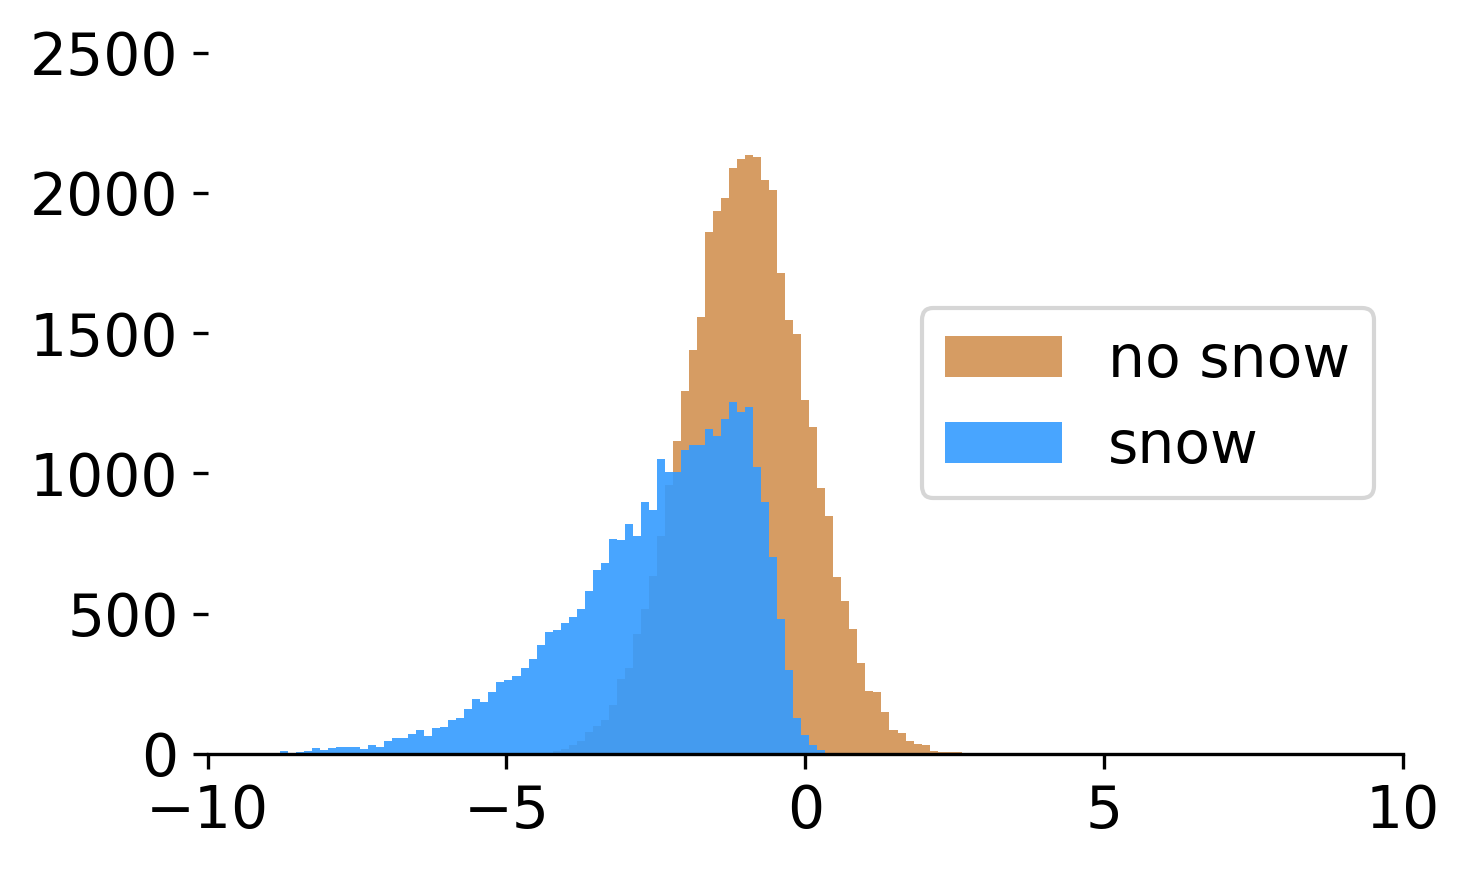

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skewnorm

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample data that resembles the distributions in the image
# Snow: left-skewed distribution peaking around -1.5 dB with peak at 1500
# Using negative skewness for left skew
n_snow = 30000
skewness = -8  # Negative skew (tail extends left)
snow_data = skewnorm.rvs(skewness, loc=-0.5, scale=2.5, size=n_snow)

# No snow: centered around 0 dB with peak around 2500
n_no_snow = 40000
no_snow_data = np.random.normal(loc=-1, scale=1, size=n_no_snow)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(5, 3),dpi=300)

# Create overlapping histograms
bins = np.linspace(-10, 10, 150)
ax.hist(no_snow_data, bins=bins, alpha=0.9, label='no snow', color='#d29152', edgecolor='none')

ax.hist(snow_data, bins=bins, alpha=0.9, label='snow', color='#349bff', edgecolor='none')

# Set labels and title
ax.set_xlabel('', fontsize=12)
ax.set_ylabel('', fontsize=12)
ax.set_title('', fontsize=12)

# Add legend
ax.legend(loc='center right', fontsize=14,)

# Set axis limits to match the original
ax.set_xlim(-10, 10)
ax.set_ylim(0, 2500)

# turn off y-axis spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)

# x ticks should only be -10, 0, 10
ax.set_xticks([-10, -5, 0, 5, 10])
# make x tick and y tick labels larger
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Adjust layout
fig.tight_layout()


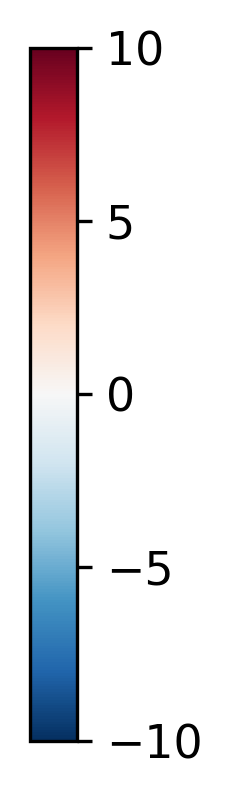

In [52]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase

# Create figure with just the colorbar
fig, ax = plt.subplots(figsize=(0.20, 3),dpi=300)

# Create colormap and normalization
cmap = plt.cm.RdBu_r  # _r reverses it so red is positive, blue is negative
norm = mcolors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

# Create colorbar
cb = ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

# Set label
cb.set_label('', fontsize=12)

# Set ticks
cb.set_ticks([-10, -5, 0, 5, 10])
cb.ax.tick_params(labelsize=11)


In [2]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-02-26 21:38 UTC (337.9 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [15]:
tile_gdf = config.valid_tiles_gdf
gdf = tile_gdf[tile_gdf['success'] == True]
# also filter to row, col being unique (some tiles were re-run and have multiple entries, but we only want to count them once for the CPU-core-hours calculation)
gdf = gdf.drop_duplicates(subset=['row', 'col'])
gdf

,row,col,percent_valid_snow_pixels,geometry,s1_rtc_ds_dims,runoff_onsets_dims,tr_2015,tr_2016,tr_2017,tr_2018,...,pix_ct_2020,pix_ct_2021,pix_ct_2022,pix_ct_2023,pix_ct_2024,start_time,total_time,success,error_messages,cpu_core_hours
1995,14,152,100.0,"POLYGON ((44.13388 60.45558, 44.13388 58.98102...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 8, 'latitude': 2048, 'longitude...",NaN,NaN,11.969,11.830,...,4190669.0,0.0,0.0,NaN,NaN,1.752603e+09,157.709109,True,[],1.051394
1459,11,181,100.0,"POLYGON ((86.89617 64.87926, 86.89617 63.4047,...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 8, 'latitude': 2048, 'longitude...",NaN,NaN,13.090,12.023,...,3949112.0,343087.0,487.0,NaN,NaN,1.752623e+09,265.599939,True,[],1.770666
1460,11,182,100.0,"POLYGON ((88.37073 64.87926, 88.37073 63.4047,...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 8, 'latitude': 2048, 'longitude...",NaN,NaN,12.700,11.833,...,4183470.0,141554.0,44.0,NaN,NaN,1.752623e+09,265.100669,True,[],1.767338
1461,11,183,100.0,"POLYGON ((89.84529 64.87926, 89.84529 63.4047,...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 8, 'latitude': 2048, 'longitude...",NaN,NaN,6.910,6.338,...,3307509.0,3945438.0,216.0,NaN,NaN,1.752623e+09,258.516251,True,[],1.723442
1462,11,184,100.0,"POLYGON ((91.31985 64.87926, 91.31985 63.4047,...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 8, 'latitude': 2048, 'longitude...",NaN,NaN,14.750,13.070,...,25964.0,4182487.0,103.0,NaN,NaN,1.752623e+09,265.331452,True,[],1.768876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,78,239,0.0,"POLYGON ((172.42073 -33.91635, 172.42073 -35.3...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 10, 'latitude': 2048, 'longitud...",11.9,9.65,4.500,4.500,...,452.0,176.0,7.0,1749.0,763.0,1.757106e+09,728.045361,True,[],4.853636
4636,78,240,0.0,"POLYGON ((173.89529 -33.91635, 173.89529 -35.3...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 10, 'latitude': 2048, 'longitud...",NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,161.0,39.0,1.757106e+09,541.345649,True,[],3.608971
4637,79,72,0.0,"POLYGON ((-73.83103 -35.39092, -73.83103 -36.8...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 10, 'latitude': 2048, 'longitud...",23.1,22.00,11.900,24.000,...,33434.0,7570.0,52588.0,54670.0,291876.0,1.757539e+09,566.824425,True,[],3.778830
4641,79,220,0.0,"POLYGON ((144.40406 -35.39092, 144.40406 -36.8...","{'latitude': 2048, 'longitude': 2048, 'time': ...","{'water_year': 10, 'latitude': 2048, 'longitud...",NaN,NaN,NaN,NaN,...,0.0,0.0,203.0,22.0,69.0,1.757539e+09,736.753912,True,[],4.911693


In [16]:
cores_per_tile = (60 / 10) * 4  # 24
gdf['cpu_core_hours'] = (gdf['total_time'] / 3600) * cores_per_tile

# Report these
print(f"Tiles: {len(gdf)}")
print(f"CPU-core-hours per tile: median={gdf['cpu_core_hours'].median():.1f}, mean={gdf['cpu_core_hours'].mean():.1f}")
print(f"Total CPU-core-hours: {gdf['cpu_core_hours'].sum():.0f}")

Tiles: 4453
CPU-core-hours per tile: median=4.7, mean=5.5
Total CPU-core-hours: 24279


In [ ]:
cluster = coiled.Cluster(name='compress_zarr',
                         idle_timeout="10 minutes",
                         n_workers=1,
                         worker_memory="256 GB",
                         worker_disk_size="200 GB",
                         #worker_cpu=2,
                         #scheduler_memory="16 GB",
                         spot_policy="spot",
                         environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
                         workspace="uwtacolab", #"azure"
                         )

client = cluster.get_client()

In [ ]:
import subprocess
import tempfile
import os

def compress_zarr_archive(config, zarr_path, output_name):
    """
    Download zarr, compress with LZMA using tar, upload compressed archive.
    """
    try:
        # Create temp directory
        with tempfile.TemporaryDirectory() as tmpdir:
            print(f"Downloading {zarr_path}...")
            local_zarr = os.path.join(tmpdir, 'data.zarr')
            config.azure_blob_fs.download(zarr_path, local_zarr, recursive=True)
            
            print(f"Compressing with parallel xz...")
            archive_path = os.path.join(tmpdir, f'{output_name}.tar.xz')
            
            # Create tar and pipe to xz with multi-threading
            cmd = f"tar -c -C {tmpdir} data.zarr | xz -9 -T0 > {archive_path}"
            subprocess.run(cmd, shell=True, check=True)
            
            compressed_size = os.path.getsize(archive_path)
            print(f"Compressed size: {compressed_size / 1e9:.2f} GB")
            
            # Upload compressed archive
            upload_path = f'snowmelt/snowmelt_runoff_onset/compressed/{output_name}.tar.xz'
            print(f"Uploading to {upload_path}...")
            config.azure_blob_fs.upload(archive_path, upload_path)
            
            return {
                'status': 'success',
                'archive_path': upload_path,
                'size_gb': compressed_size / 1e9
            }
            
    except Exception as e:
        import traceback
        return {
            'status': 'error',
            'error': str(e),
            'traceback': traceback.format_exc()
        }

In [ ]:
# Submit job
zarr_path = 'snowmelt/snowmelt_runoff_onset/global_v9.zarr'
output_name = 'global_v9'

In [ ]:
future = client.submit(compress_zarr_archive, config, zarr_path, output_name)
future

In [ ]:
result = future.result()
result

In [ ]:
config.azure_blob_fs.ls('snowmelt/snowmelt_runoff_onset/global_v9.zarr',detail=True)

In [ ]:
#config.azure_blob_fs.download('snowmelt/snowmelt_runoff_onset/global_v9.zarr',lpath="~/repos/global_snowmelt_runoff_onset/dataset/global_v9.zarr",recursive=True)

In [ ]:
def get_folder_size_recursive(fs, path):
    total_size = 0
    files = fs.find(path, detail=True) 

    for file_info in files.values():
        if file_info['type'] == 'file':
            total_size += file_info['size']
    return total_size

In [ ]:
folder_path = 'snowmelt/snowmelt_runoff_onset/global_v9.zarr'
size = get_folder_size_recursive(config.azure_blob_fs, folder_path)

print(f"The recursive size of '{folder_path}' is: {size/1e9} GB")

In [ ]:
global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
global_ds

In [ ]:
global_ds['latitude'].encoding

In [ ]:
global_ds['runoff_onset'].encoding

In [ ]:
all_vars = list(global_ds.data_vars) + ['latitude', 'longitude','water_year']
total_size = 0
for var in all_vars:
    print(f"Current compression for variable: {var}")
    print(global_ds[var].encoding)
    folder_path = f'snowmelt/snowmelt_runoff_onset/global_v9.zarr/{var}'
    size = get_folder_size_recursive(config.azure_blob_fs, folder_path)
    total_size += size
    print(f"The current recursive size of '{folder_path}' is: {size/1e9} GB")
    print("-----")
    
print(f"Total size of all variables: {total_size/1e9} GB")

In [ ]:
# # get encoding from existing dataset, just modify compression
# encoding = {}
# for var in global_ds.data_vars:
#     encoding[var] = global_ds[var].encoding
#     # encoding[var]["compressor"] = zarr.Blosc(cname="zstd", clevel=5, shuffle=zarr.Blosc.BITSHUFFLE)
#     # previous encoding was zarr.Blosc(cname="zstd"), clevel=5, shuffle=SHUFFLE, blocksize=0)
#     encoding[var]["compressor"] = zarr.Blosc(cname="zstd", clevel=9, shuffle=zarr.Blosc.BITSHUFFLE)
# encoding

# new_store_path = 'snowmelt/snowmelt_runoff_onset/compressed/global_v9_compressed.zarr'
# target_store = config.azure_blob_fs.get_mapper(new_store_path)
# target_store

# global_ds.to_zarr(
#     target_store,
#     encoding=encoding,
#     mode='w',
#     write_empty_chunks=False,
#     consolidated=True,
# )

In [ ]:
new_store_path = 'snowmelt/snowmelt_runoff_onset/compressed/global_v9_compressed.zarr'

def compress_zarr(config, new_store_path):
    try:
        global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')

        # get encoding from existing dataset, just modify compression
        encoding = {}
        for var in global_ds.data_vars:
            encoding[var] = global_ds[var].encoding
            encoding[var]["compressor"] = zarr.Blosc(cname="zlib", clevel=9, shuffle=zarr.Blosc.SHUFFLE)

        target_store = config.azure_blob_fs.get_mapper(new_store_path)

        global_ds.to_zarr(
            target_store,
            encoding=encoding,
            mode='w',
            write_empty_chunks=False,
            consolidated=True,
        )
        return f"Successfully compressed zarr to {new_store_path}"
    except Exception as e:
        print(f"Error compressing zarr: {e}")
        
        
future = client.submit(compress_zarr, config, new_store_path)
future

In [ ]:
result = future.result()
result

In [ ]:
client.restart()

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from pathlib import Path
import tempfile
import time

import uuid

def test_compression_subset(config, cname, clevel, shuffle_type):
    """
    Test compression on 2020 + composites, return sizes.
    This is basically your original code but on a subset.
    """
    try:
        global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
        
        # Subset: just 2020 for annual vars, all composites
        annual_vars = ['runoff_onset', 'temporal_resolution']
        composite_vars = ['runoff_onset_median', 'runoff_onset_mad', 'temporal_resolution_median']
        
        # Select water_year 2020 (index 5) for annual products
        subset = global_ds[annual_vars].isel(water_year=5)
        # Add all composite products (they have no time dimension)
        for var in composite_vars:
            subset[var] = global_ds[var]
        
        # Create compressor
        if shuffle_type == 'SHUFFLE':
            compressor = zarr.Blosc(cname=cname, clevel=clevel, shuffle=zarr.Blosc.SHUFFLE)
        elif shuffle_type == 'BITSHUFFLE':
            compressor = zarr.Blosc(cname=cname, clevel=clevel, shuffle=zarr.Blosc.BITSHUFFLE)
        
        # Get encoding from existing dataset, just modify compression
        encoding = {}
        for var in subset.data_vars:
            encoding[var] = subset[var].encoding
            encoding[var]["compressor"] = compressor
        
        # Write to test location
        test_id = str(uuid.uuid4())[:8]
        test_store_path = f'snowmelt/snowmelt_runoff_onset/compressed/test_{test_id}_{cname}_{clevel}_{shuffle_type}.zarr'
        target_store = config.azure_blob_fs.get_mapper(test_store_path)
        
        subset.to_zarr(
            target_store,
            encoding=encoding,
            mode='w',
            write_empty_chunks=False,
            consolidated=True,
        )
        
        # Measure sizes
        sizes = {}
        for var in subset.data_vars:
            var_folder = f'{test_store_path}/{var}'
            files = config.azure_blob_fs.find(var_folder, detail=True)
            var_size = sum(f['size'] for f in files.values() if f['type'] == 'file')
            sizes[var] = var_size
        
        # Cleanup
        config.azure_blob_fs.rm(test_store_path, recursive=True)
        
        return sizes
        
    except Exception as e:
        return {'error': str(e)}


In [ ]:
# Test different configs
configs_to_test = [
    ('zstd', 5, 'SHUFFLE'),   # current
    ('zstd', 9, 'SHUFFLE'),
    ('zstd', 9, 'BITSHUFFLE'),
    ('zlib', 9, 'SHUFFLE'),
    ('zlib', 9, 'BITSHUFFLE'),
]

results = []
for cname, clevel, shuffle_type in configs_to_test:
    config_name = f"{cname}_clevel{clevel}_{shuffle_type}"
    print(f"Testing {config_name}...")
    
    future = client.submit(test_compression_subset, config, cname, clevel, shuffle_type)
    sizes = future.result()
    
    if 'error' in sizes:
        print(f"  ERROR: {sizes['error']}")
        continue
    
    # Calculate extrapolated sizes
    annual_size = (sizes['runoff_onset'] + sizes['temporal_resolution']) * 10 / 1e9  # 1 year → 10 years
    composite_size = (sizes['runoff_onset_median'] + sizes['runoff_onset_mad'] + sizes['temporal_resolution_median']) / 1e9
    total_estimated = annual_size + composite_size
    
    # Current sizes
    current_annual = 28.288 + 14.688  # GB
    current_composite = 6.844 + 7.711 + 2.861  # GB
    current_total = 60.392  # GB
    
    savings = current_total - total_estimated
    savings_pct = (savings / current_total) * 100
    
    results.append({
        'config': config_name,
        'runoff_onset_GB': sizes['runoff_onset'] * 10 / 1e9,
        'temporal_resolution_GB': sizes['temporal_resolution'] * 10 / 1e9,
        'composites_GB': composite_size,
        'total_GB': total_estimated,
        'savings_GB': savings,
        'savings_pct': savings_pct,
        'makes_cutoff': total_estimated < 50
    })
    
    print(f"  Total: {total_estimated:.2f} GB ({savings:.2f} GB savings, {savings_pct:.1f}%)")
    print(f"  {'✅ PASS' if total_estimated < 50 else '❌ FAIL'} 50GB cutoff")


In [ ]:
# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
df = pd.DataFrame(results)
print(df[['config', 'total_GB', 'savings_GB', 'makes_cutoff']].to_string(index=False))

best = df.loc[df['total_GB'].idxmin()]
print(f"\n🎯 BEST: {best['config']}")
print(f"   Estimated: {best['total_GB']:.2f} GB")
print(f"   Margin: {50 - best['total_GB']:.2f} GB")

In [ ]:

# Same compression configs
compression_configs = {
    'current_zstd_clevel5_shuffle': ('zstd', 5, 'SHUFFLE'),
    'zstd_clevel9_shuffle': ('zstd', 9, 'SHUFFLE'),
    'zstd_clevel9_bitshuffle': ('zstd', 9, 'BITSHUFFLE'),
    'zlib_clevel9_shuffle': ('zlib', 9, 'SHUFFLE'),
    'zlib_clevel9_bitshuffle': ('zlib', 9, 'BITSHUFFLE'),
}

# Submit to cluster
print("Submitting compression test job to Coiled cluster...")
future = client.submit(test_compression_temporal_subset, config, compression_configs)
print(f"Job submitted: {future}")


In [ ]:

# Get results
results_list = future.result()
results_list

In [ ]:
results_df = pd.DataFrame(results_list)

# Display results
print("\n" + "="*80)
print("COMPRESSION COMPARISON SUMMARY")
print("="*80)
print(results_df[['config_name', 'total_estimated_GB', 'total_savings_GB', 'makes_cutoff']].to_string(index=False))

# Show best option
best_idx = results_df['total_estimated_GB'].idxmin()
best = results_df.loc[best_idx]
print(f"\n🎯 RECOMMENDED: {best['config_name']}")
print(f"   Estimated: {best['total_estimated_GB']:.2f} GB")
print(f"   Margin: {50 - best['total_estimated_GB']:.2f} GB under limit")

# Save results
results_df.to_csv('compression_test_results.csv', index=False)
print("\n📁 Results saved to: compression_test_results.csv")

In [ ]:
compression_configs = {
    'current_zstd_clevel5_shuffle': ('zstd', 5, 'SHUFFLE'),
    'zstd_clevel9_shuffle': ('zstd', 9, 'SHUFFLE'),
    'zstd_clevel9_bitshuffle': ('zstd', 9, 'BITSHUFFLE'),
    'zlib_clevel9_shuffle': ('zlib', 9, 'SHUFFLE'),
    'zlib_clevel9_bitshuffle': ('zlib', 9, 'BITSHUFFLE'),
}

# Submit to cluster
print("Submitting compression test job to Coiled cluster...")
future = client.submit(test_compression_temporal_subset, config, compression_configs)
print(f"Job submitted: {future}")

In [ ]:
# Get results
results_list = future.result()
results_list

In [ ]:
# Convert to DataFrame for analysis
results_df = pd.DataFrame(results_list)

# Display summary table
print("\n" + "="*80)
print("COMPRESSION COMPARISON SUMMARY")
print("="*80)

summary_cols = [
    'config_name',
    'total_estimated_GB',
    'total_savings_GB',
    'total_savings_pct',
    'makes_cutoff'
]

print(results_df[summary_cols].to_string(index=False))

# Show detailed breakdown by variable
print("\n" + "="*80)
print("PER-VARIABLE COMPRESSION ANALYSIS:")
print("="*80)

# Check if different variables prefer different compressors
for var in ['runoff_onset', 'temporal_resolution', 'runoff_onset_median', 
            'runoff_onset_mad', 'temporal_resolution_median']:
    
    if f'{var}_extrapolated_GB' in results_df.columns:
        col = f'{var}_extrapolated_GB'
    elif f'{var}_GB' in results_df.columns:
        col = f'{var}_GB'
    else:
        continue
    
    print(f"\n{var}:")
    var_results = results_df[['config_name', col, f'{var}_savings_pct']].copy()
    var_results = var_results.sort_values(col)
    print(var_results.to_string(index=False))
    
    best = var_results.iloc[0]
    print(f"  → Best: {best['config_name']} ({best[col]:.2f} GB, {best[f'{var}_savings_pct']:.1f}% savings)")

# Show which configs make the cutoff
print("\n" + "="*80)
print("ZENODO 50GB CUTOFF STATUS:")
print("="*80)
for _, row in results_df.iterrows():
    status = "✅ PASS" if row['makes_cutoff'] else "❌ FAIL"
    margin = 50 - row['total_estimated_GB']
    print(f"{row['config_name']:35s} {row['total_estimated_GB']:6.2f} GB  (margin: {margin:+.2f} GB)  {status}")

# Recommend best option
best_idx = results_df['total_estimated_GB'].idxmin()
best_config = results_df.loc[best_idx]
print("\n" + "="*80)
print(f"🎯 RECOMMENDED: {best_config['config_name']}")
print(f"  Estimated total size: {best_config['total_estimated_GB']:.2f} GB")
print(f"  Savings: {best_config['total_savings_GB']:.2f} GB ({best_config['total_savings_pct']:.1f}%)")
print(f"  Makes Zenodo cutoff: {'✅ YES' if best_config['makes_cutoff'] else '❌ NO'}")
print(f"  Safety margin: {50 - best_config['total_estimated_GB']:.2f} GB")
print("="*80)

# Check if we should use different compressors for different variables
print("\n" + "="*80)
print("VARIABLE-SPECIFIC COMPRESSION RECOMMENDATION:")
print("="*80)

for var in ['runoff_onset', 'temporal_resolution']:
    col = f'{var}_extrapolated_GB'
    best_var_idx = results_df[col].idxmin()
    best_var_config = results_df.loc[best_var_idx, 'config_name']
    best_var_size = results_df.loc[best_var_idx, col]
    
    # Compare to overall best
    overall_best_size = results_df.loc[best_idx, col]
    diff = overall_best_size - best_var_size
    
    if abs(diff) > 0.1:  # >100MB difference
        print(f"{var}: Prefers {best_var_config} ({diff:.2f} GB better)")
    else:
        print(f"{var}: No strong preference (within 100MB)")

# Save results to CSV for reference
results_df.to_csv('compression_test_results.csv', index=False)
print("\n📁 Results saved to: compression_test_results.csv")

In [ ]:
# Verify new size
new_size = get_folder_size_recursive(config.azure_blob_fs, new_store_path)
print(f"New size: {new_size/1e9:.2f} GB") # 83GB with zstd clevel 9 with bitshuffle, 55GB with zstd clevel 9 with shuffle

In [ ]:
new_global_ds = xr.open_zarr(config.azure_blob_fs.get_mapper(new_store_path), consolidated=True, decode_coords='all')
new_global_ds

In [ ]:
for var in new_global_ds.data_vars:
    print(f"Setting compression for variable: {var}")
    print(new_global_ds[var].encoding)

In [ ]:
# now compress??? then download????
client.close()

In [ ]:
# config.azure_blob_fs.download('snowmelt/snowmelt_runoff_onset/global_v5.zarr',lpath="/mnt/c/Users/elgag/Downloads/global_v5.zarr",recursive=True)
# config.azure_blob_fs.ls('snowmelt/snowmelt_runoff_onset/global_v5.zarr',detail=True)